# 001 - Stage 1: provenance signals without fine-tuning

Baseline from Zhao et al. (*Data Provenance for Image Auto-Regressive Generation*, ICLR 2026). For each family, the tokenizer's **original encoder** $E$ stands in for the paper's inverse decoder $D^{-1}$. Fine-tuning $D^{-1}$ is Stage 2.

**Goal.** Give every image one of 9 labels: 4 RAR sizes, 4 VAR depths, or `outlier`. Stage 1 measures how far the paper's signals get without fine-tuning. They are designed to separate families and outliers, not sizes, so family and outlier metrics are reported separately from overall accuracy.

**Pipeline**
1. **Feature extraction**: `scripts/extract_features.py`, run in tmux and cached to `/workspace/cache/stage1/{rar,var}.csv`. All sizes in a family share one tokenizer, so features are computed once per family, not per model. Every image is scored with both tokenizers, including the other family's images and outliers.
2. **Score selection**: one signal per family, chosen by train AUC.
3. **Family / outlier decision**: nearest family by z-score, plus a per-family outlier threshold, fit on train only.
4. **Size within the family**: per-family logistic regression on all signals.
5. **Evaluation on val, then test predictions.**

### Signals (step 1)
Notation: the family tokenizer has encoder $E$, quantizer $Q$ (features → token indices), codebook lookup $Q^{-1}$ and decoder $D$. The image is $x \in [0,1]^{3\times256\times256}$, with features $f = E(x)$, quantized features $f_Z = Q^{-1}(Q(f))$, and reconstruction $\mathrm{Rec}(x) = \mathrm{clip}_{[0,1]}\big(D(f_Z)\big)$.

| column | paper | definition | intuition |
|---|---|---|---|
| `quant` | QuantLoss, Eq. 5 | $\lVert f - f_Z\rVert^2$ | an image produced by $D$ inverts to features that already sit on codebook entries |
| `quant_p90` (RAR only) | extra | 90th percentile, over token positions, of the per-token quantization error | tail version of `quant` |
| `enc1` | EncLoss, Eq. 9 | $\lVert \mathrm{Rec}(x) - x\rVert^2$ | an image produced by $D$ survives encode → decode with little loss |
| `enc2` | denominator of Eq. 10 | $\lVert \mathrm{Rec}(\mathrm{Rec}(x)) - \mathrm{Rec}(x)\rVert^2$ | second round trip, an estimate of image complexity |
| `cal` | calibrated EncLoss, Eq. 10 | `enc1 / enc2` | removes the "simple images reconstruct well" confound |
| `comb` | combined, Eq. 11 | `quant × cal` | |
| `tok_match` | extra | fraction of token indices equal in $Q(E(x))$ and $Q(E(\mathrm{Rec}(x)))$ | tokens that stay stable under re-encoding suggest the image came from this tokenizer |

For every loss, lower = more likely from this family. For `tok_match`, higher = more likely. $\lVert\cdot\rVert^2$ is implemented as a mean squared error (MSE, mean over elements), not a sum. Inputs have a fixed size, so this is a constant rescale and does not change any ranking. Pixel losses are computed on $[0,1]$ images for both families (VAR's encoder works in $[-1,1]$ internally).

VAR quantizes with a multi-scale residual scheme: $f_Z = \sum_{k=1}^{10} \phi_k\big(\mathrm{up}(Z[t_k])\big)$, where $t_k$ are the scale-$k$ tokens, $\mathrm{up}$ is bicubic upsampling to 16×16, and $\phi_k$ is VAR's per-scale residual conv. The tokens are chosen greedily, scale by scale (Alg. 2). The paper's optimized token search (Alg. 3) is implemented (`--var-iters`) but disabled here (`--var-iters 0`). With the plain encoder it moved QuantLoss by under 3% at ~2.3 s/image, so it is deferred to Stage 2.

### Decision rule (deliberate choice)
The paper scores each model with a separate yes/no threshold, but the task needs exactly one label per image. Here each family gets one score, standardised on its own train images. The image goes to the family with the lowest z-score, and is an outlier if that z exceeds the family's train q-quantile (details in *Decision rule* below). Train has no outliers, so nothing is tuned on outliers, and val stays a clean held-out evaluation for RAR, VAR and outliers.

The signals are not expected to separate sizes, so the size classifier mainly measures how much size information they carry.

**Reported:** overall accuracy, family accuracy (RAR / VAR / outlier), outlier recall and precision, per-family recall, and size accuracy given the correct family.

Regenerate features:
```
python scripts/extract_features.py --family rar
python scripts/extract_features.py --family var --var-iters 0
```

## Setup
Install dependencies into the active kernel (`%pip` targets the kernel's own environment). Then put the repo root first on `sys.path`, so `tracer` resolves to this repo's package, and import the shared constants (`LABELS`, `FAMILY_OF`, `CACHE`), the Stage 1 model and the metrics.

In [35]:
%pip install numpy pandas matplotlib scikit-learn tracer torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
import sys, json
from pathlib import Path
REPO = Path("/workspace/iar-model-tracer")
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from tracer.common import CACHE, LABELS, LABEL2IDX, FAMILY_OF, build_index
from tracer.stage1 import NearestFamilyThreshold, KNOWN_FAMILIES
from tracer.metrics import report, confusion, family_confusion

OUT = CACHE / "stage1"
pd.set_option("display.precision", 3)
pd.set_option("display.width", 200)

## Load cached features and sanity checks

1. **Join** the two per-family feature tables on `key` = `split/label/file name`. File names repeat across class folders, so the key includes split and label. The join is checked to be 1:1.
2. **Index check.** Rebuild the image index from the data folders, and assert that it matches the cached rows exactly (same order, same labels). This catches a stale cache.
3. **Label mapping.** The label comes from the folder name, and the family from the label prefix (`FAMILY_OF`). The integer indices (`LABEL2IDX`) are only printed, never used, so a shifted mapping cannot silently corrupt labels.
4. **Feature check.** No NaNs, and every loss is strictly positive, which the log transform below needs. `tok_match` may be 0.
5. **Deduplicate.** With the token search off, `var_quant == var_quant_greedy` and `var_comb == var_comb_greedy`, so the `_greedy` copies are dropped. That leaves **13 features**: 7 RAR and 6 VAR.
6. **Split** into train (800 = 8 known labels × 100, no outliers), val (450 = 9 labels × 50, including 50 outliers) and test (9,800 unlabeled).

In [37]:
rar = pd.read_csv(OUT / "rar.csv")
var = pd.read_csv(OUT / "var.csv")
df = rar.merge(var.drop(columns=["split", "label", "family", "name"]), on="key", validate="1:1")

# The index is rebuilt from folder names and must match the cached rows exactly.
idx = build_index()
assert df.key.tolist() == idx.key.tolist()
assert (df.label.dropna() == idx.label.dropna()).all()

# Label mapping: folder name -> label string -> family. No integer indices are used, so nothing can silently shift.
assert set(df.label.dropna()) == set(LABELS)
assert all(df.family.dropna() == df.label.dropna().map(FAMILY_OF))
print("LABEL2IDX:", LABEL2IDX)

FEATS = [c for c in df.columns if c[:4] in ("rar_", "var_")]
assert df[FEATS].notna().all().all() and (df[FEATS].drop(columns=["rar_tok_match", "var_tok_match"]) > 0).all().all()
# Without the token search, var_quant == var_quant_greedy and var_comb == var_comb_greedy. Keep one copy of each.
assert np.allclose(df.var_quant, df.var_quant_greedy) and np.allclose(df.var_comb, df.var_comb_greedy)
FEATS = [c for c in FEATS if c not in ("var_quant_greedy", "var_comb_greedy")]

train, val, test = (df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"])
print({s: len(d) for s, d in [("train", train), ("val", val), ("test", test)]})
print("features:", FEATS)
pd.crosstab(df.label.fillna("(test)"), df.split)

LABEL2IDX: {'var16': 0, 'var20': 1, 'var24': 2, 'var30': 3, 'rarb': 4, 'rarl': 5, 'rarxl': 6, 'rarxxl': 7, 'outlier': 8}
{'train': 800, 'val': 450, 'test': 9800}
features: ['rar_quant', 'rar_quant_p90', 'rar_enc1', 'rar_enc2', 'rar_cal', 'rar_comb', 'rar_tok_match', 'var_quant', 'var_enc1', 'var_enc2', 'var_cal', 'var_comb', 'var_tok_match']


split,test,train,val
label,,,
(test),9800,0,0
outlier,0,0,50
rarb,0,100,50
rarl,0,100,50
rarxl,0,100,50
rarxxl,0,100,50
var16,0,100,50
var20,0,100,50
var24,0,100,50


## Choosing each family's score (train only)

The decision rule needs one score $s_f$ per family $f$, where lower = more likely generated by $f$. The candidates are family $f$'s own signals (`rar_*` for RAR, `var_*` for VAR).

**Criterion: ROC AUC.** For a signed score $g$ (higher = own family),
$$\mathrm{AUC} = P\big(g(x^+) > g(x^-)\big), \qquad x^+ \text{ from family } f,\; x^- \text{ not from } f.$$
0.5 is chance and 1.0 is a perfect ranking. Losses enter as $g = -\log s$: the sign is flipped so that higher = own family. `tok_match` enters unchanged, since higher already means own family. Log is monotone, so it does not change the AUC.

- **Selection column:** `train AUC own vs other fam`. Train has no outliers, so the negatives $x^-$ are the other known family.
- **Reference only, not used for selection:** `val AUC own vs rest` (negatives = other family + outliers) and `val AUC own vs outlier` (negatives = outliers only).

The selected score must be a loss, because the decision rule takes $\log s_f$ and assumes lower = own family. `tok_match` is therefore excluded from selection. For each family, $s_f$ is the loss with the highest train AUC.

In [38]:
def signed(d, c):
    return d[c].values if c.endswith("tok_match") else -np.log(d[c].values)  # higher = more likely own family

rows = []
for fam in KNOWN_FAMILIES:
    for c in [c for c in FEATS if c.startswith(fam + "_")]:
        vo = val[val.family.isin([fam, "outlier"])]
        rows.append({"family": fam, "signal": c,
                     "train AUC own vs other fam": roc_auc_score(train.family == fam, signed(train, c)),
                     "val AUC own vs rest": roc_auc_score(val.family == fam, signed(val, c)),
                     "val AUC own vs outlier": roc_auc_score(vo.family == fam, signed(vo, c))})
auc = pd.DataFrame(rows).set_index(["family", "signal"])
display(auc)

# The final score must be a loss (lower = own family), as the decision rule assumes.
loss_like = auc[~auc.index.get_level_values("signal").str.endswith("tok_match")]
SCORE = {fam: loss_like.loc[fam]["train AUC own vs other fam"].idxmax() for fam in KNOWN_FAMILIES}
print("selected scores:", SCORE)

train AUC own vs other fam  val AUC own vs rest  val AUC own vs outlier
family signal                                                                                
rar    rar_quant                           0.710                0.777                   0.789
       rar_quant_p90                       0.689                0.753                   0.764
       rar_enc1                            0.766                0.773                   0.753
       rar_enc2                            0.608                0.634                   0.641
       rar_cal                             0.900                0.906                   0.878
       rar_comb                            0.880                0.900                   0.895
       rar_tok_match                       0.835                0.868                   0.935
var    var_quant                           0.517                0.473                   0.435
       var_enc1                            0.545                0.518                   0.544
       var_enc2                            0.420                0.393                   0.428
       var_cal                             0.945                0.941                   0.909
       var_comb                            0.687                0.643                   0.581
       var_tok_match                       0.731                0.790                   0.819

selected scores: {'rar': 'rar_cal', 'var': 'var_cal'}


### Selected scores on val
Distribution of $\log s_f$ for each selected score, by true val label. If the score works, family $f$'s four sizes sit low, while the other family and the outliers sit higher. The outlier threshold relies on this gap. The score is not built to separate sizes, so the four sizes within a family are expected to overlap.

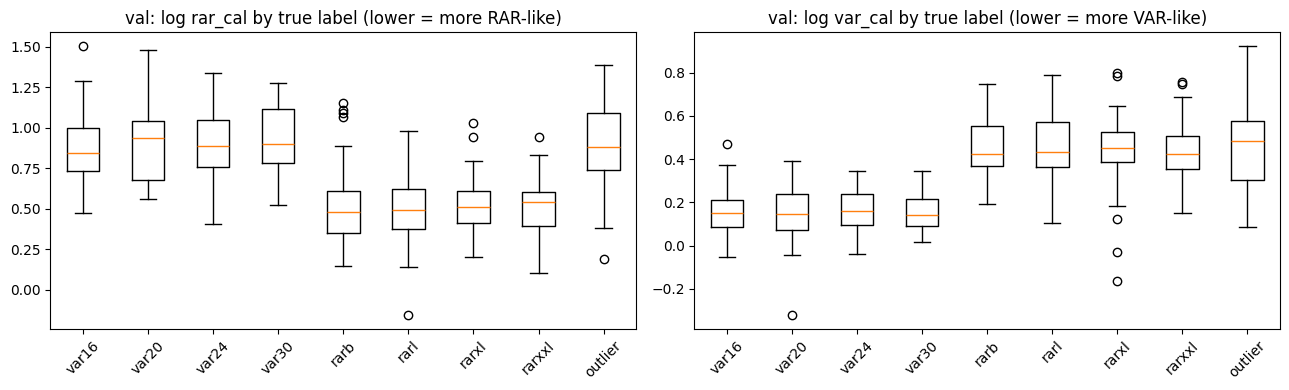

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for ax, fam in zip(axs, KNOWN_FAMILIES):
    c = SCORE[fam]
    groups = [np.log(val[val.label == l][c]) for l in LABELS]
    ax.boxplot(groups, tick_labels=LABELS)
    ax.set_title(f"val: log {c} by true label (lower = more {fam.upper()}-like)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## Decision rule

All parameters are fit on train only (`NearestFamilyThreshold.fit`).

**1. Standardise each family's score** on that family's own train images. The losses are positive and right-skewed, so they are logged first:
$$\mu_f = \operatorname*{mean}_{x \in \text{train}_f} \log s_f(x), \qquad \sigma_f = \operatorname*{std}_{x \in \text{train}_f} \log s_f(x), \qquad z_f(x) = \frac{\log s_f(x) - \mu_f}{\sigma_f}.$$
$z_f(x)$ is computed for every image and for both $f \in \{\text{rar}, \text{var}\}$. It is the number of train standard deviations by which $x$ is less typical than an average image of family $f$. This puts two scores with different units on a common scale. $\sigma_f$ is the population standard deviation (ddof = 0).

**2. Nearest family:** $\hat f(x) = \arg\min_f z_f(x)$, with ties going to RAR.

**3. Outlier threshold:** $\tau_f$ is the q-quantile of $\{z_f(x) : x \in \text{train}_f\}$. An image is predicted `outlier` if $z_{\hat f}(x) > \tau_{\hat f}$, i.e. if it is less typical than a fraction q of the nearest family's own train images. By construction, about $1-q$ of each family's train images are rejected (the in-sample false-rejection rate).

**q = 0.95 is fixed in advance** (the standard 5% in-distribution false-rejection budget), not tuned on val. The q sweep further down is only a diagnostic.

**4. Size:** if $\hat f$ is a known family, a `StandardScaler → LogisticRegression` (C = 1) picks one of its 4 sizes. It is trained on family $\hat f$'s train images, using all 13 features (losses logged, `tok_match` as-is).

**Plot (val).** Each point is one image at $(z_\text{rar}, z_\text{var})$. The dashed diagonal is the family boundary: above it $z_\text{rar} < z_\text{var}$ (→ RAR), below it → VAR. The dotted lines are the outlier thresholds: $z_\text{rar} = \tau_\text{rar}$ above the diagonal, and $z_\text{var} = \tau_\text{var}$ below it. Together they enclose the top-right outlier region, where an image is atypical for both families.

tau: {'rar': np.float64(1.683), 'var': np.float64(1.43)}


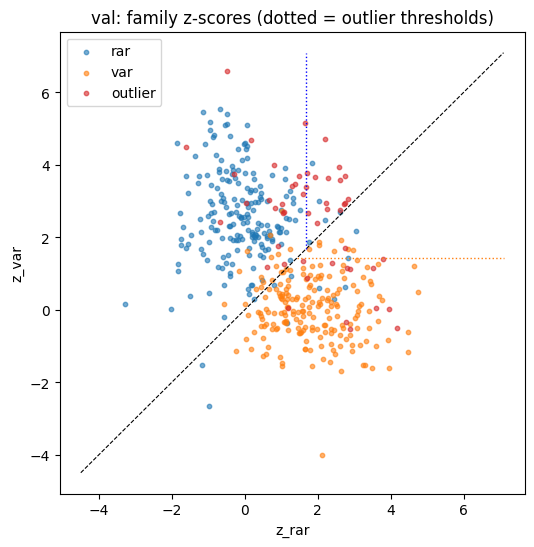

In [40]:
Q = 0.95
model = NearestFamilyThreshold(SCORE, q=Q, size_cols=FEATS).fit(train)
print("tau:", {k: round(v, 3) for k, v in model.tau_.items()})

z = model.family_z(val).assign(label=val.label, family=val.family)
fig, ax = plt.subplots(figsize=(6, 6))
for fam, col in [("rar", "tab:blue"), ("var", "tab:orange"), ("outlier", "tab:red")]:
    s = z[z.family == fam]
    ax.scatter(s.z_rar, s.z_var, s=10, alpha=0.6, c=col, label=fam)
lim = [min(z.z_rar.min(), z.z_var.min()) - 0.5, max(z.z_rar.max(), z.z_var.max()) + 0.5]
ax.plot(lim, lim, "k--", lw=0.8)
ax.plot([model.tau_["rar"], model.tau_["rar"]], [model.tau_["rar"], lim[1]], "b:", lw=1)
ax.plot([model.tau_["var"], lim[1]], [model.tau_["var"], model.tau_["var"]], ":", c="tab:orange", lw=1)
ax.set_xlabel("z_rar"); ax.set_ylabel("z_var"); ax.set_title("val: family z-scores (dotted = outlier thresholds)")
ax.legend(); plt.show()

## Results

Metrics from `tracer.metrics.report`, computed on label strings. Family = label prefix.

| metric | definition |
|---|---|
| `accuracy` | exact 9-class label match (the task metric) |
| `family_accuracy` | predicted family = true family, over RAR / VAR / outlier |
| `outlier_recall` | share of true outliers predicted `outlier` |
| `outlier_precision` | share of `outlier` predictions that are true outliers |
| `size_accuracy_given_family` | exact label match, among RAR / VAR images whose family was predicted correctly |
| `family_recall_<f>` | share of family-$f$ images predicted as family $f$ |

The train column is in-sample, since the model was fit on it. Train also has no outliers, so outlier recall is NaN, and outlier precision is 0 because every train image predicted `outlier` is wrong. The two tables below are the family-level and full-label confusion matrices on val (rows = true, columns = predicted).

In [41]:
pred_train, pred_val = model.predict(train), model.predict(val)
res = pd.DataFrame({"train (in-sample)": report(train.label, pred_train), "val": report(val.label, pred_val)})
display(res)
display(family_confusion(val.label, pred_val))
display(confusion(val.label, pred_val))

,train (in-sample),val
n,800.000,450.000
accuracy,0.304,0.236
family_accuracy,0.881,0.838
outlier_recall,NaN,0.320
outlier_precision,0.000,0.533
size_accuracy_given_family,0.345,0.249
family_recall_rar,0.895,0.925
family_recall_var,0.868,0.880
family_recall_outlier,NaN,0.320


pred,rar,var,outlier
true,,,
rar,185,8,7
var,17,176,7
outlier,21,13,16


pred,var16,var20,var24,var30,rarb,rarl,rarxl,rarxxl,outlier
true,,,,,,,,,
var16,15,5,14,9,2,1,2,0,2
var20,15,5,14,11,0,1,3,0,1
var24,6,9,16,12,0,2,3,0,2
var30,9,8,15,13,1,1,1,0,2
rarb,1,0,0,0,8,8,7,22,4
rarl,1,0,0,0,12,8,12,15,2
rarxl,5,0,0,0,11,8,9,17,0
rarxxl,1,0,0,0,10,14,8,16,1
outlier,4,6,3,0,12,7,0,2,16


### Size baseline
For comparison, `size_cols=None` keeps the same family / outlier rule, but always predicts one fixed size per family (`rarb` for RAR, `var16` for VAR). Val is size-balanced (50 per size), so this baseline gets about 25% size accuracy given the correct family. It is exactly 25% only if family errors are spread evenly across sizes. All family and outlier metrics are identical to the LR model by construction.

In [42]:
fixed = NearestFamilyThreshold(SCORE, q=Q, size_cols=None).fit(train)
pd.DataFrame({"LR on signals": report(val.label, pred_val), "fixed size": report(val.label, fixed.predict(val))})

,LR on signals,fixed size
n,450.000,450.000
accuracy,0.236,0.231
family_accuracy,0.838,0.838
outlier_recall,0.320,0.320
outlier_precision,0.533,0.533
size_accuracy_given_family,0.249,0.244
family_recall_rar,0.925,0.925
family_recall_var,0.880,0.880
family_recall_outlier,0.320,0.320


### Diagnostic: sensitivity to q (val)
The full model is refit on train for each q and evaluated on val. A higher q raises every $\tau_f$, so fewer images are rejected: outlier recall falls, while RAR / VAR recall and outlier precision rise. For reference only; q is not chosen from this table.

In [43]:
sweep = {q: report(val.label, NearestFamilyThreshold(SCORE, q=q, size_cols=FEATS).fit(train).predict(val))
         for q in [0.8, 0.85, 0.9, 0.95, 0.975, 0.99]}
pd.DataFrame(sweep).T[["accuracy", "family_accuracy", "outlier_recall", "outlier_precision",
                       "family_recall_rar", "family_recall_var"]]

,accuracy,family_accuracy,outlier_recall,outlier_precision,family_recall_rar,family_recall_var
0.800,0.262,0.793,0.72,0.371,0.830,0.775
0.850,0.260,0.818,0.64,0.427,0.855,0.825
0.900,0.251,0.833,0.50,0.500,0.905,0.845
0.950,0.236,0.838,0.32,0.533,0.925,0.880
0.975,0.218,0.836,0.14,0.583,0.945,0.900
0.990,0.207,0.831,0.02,1.000,0.950,0.915


## Test predictions
The train-fit model (q = 0.95) is applied to the 9,800 test images, and `image_name,label` is written to `/workspace/cache/stage1/submission_stage1.csv` as the Stage 1 baseline submission. It lives in the cache and is not committed. The asserts enforce the submission rules: 9,800 rows, unique `.png` names, and labels from `LABELS`. The table compares predicted family shares on test with val's predicted and true shares.

In [44]:
pred_test = model.predict(test)
sub = pd.DataFrame({"image_name": test.name, "label": pred_test})
assert len(sub) == 9800 and sub.image_name.is_unique and sub.image_name.str.endswith(".png").all()
assert sub.label.isin(LABELS).all()
sub.to_csv(OUT / "submission_stage1.csv", index=False)
print(OUT / "submission_stage1.csv")
display(pd.DataFrame({"test": pred_test.map(FAMILY_OF).value_counts(normalize=True),
                      "val pred": pred_val.map(FAMILY_OF).value_counts(normalize=True),
                      "val true": val.family.value_counts(normalize=True)}))

/workspace/cache/stage1/submission_stage1.csv


,test,val pred,val true
rar,0.453,0.496,0.444
var,0.333,0.438,0.444
outlier,0.214,0.067,0.111


### Save run summary
Writes the selected scores, q, $\tau_f$, the size features and the train / val metrics to `/workspace/cache/stage1/metrics.json`, for comparison with later stages.

In [45]:
summary = {"score_cols": SCORE, "q": Q, "tau": model.tau_, "size_features": FEATS,
           "val": res["val"].to_dict(), "train": res["train (in-sample)"].to_dict()}
(OUT / "metrics.json").write_text(json.dumps(summary, indent=2, default=float))

1043

## Findings

Val, q = 0.95, original encoders:

| metric | val |
|---|---|
| overall accuracy | 23.6% |
| family accuracy (RAR / VAR / outlier) | 83.8% |
| family recall RAR / VAR | 92.5% / 88.0% |
| outlier recall / precision | 32.0% / 53.3% |
| size accuracy given correct family | 24.9% (chance ≈ 25%) |

1. **Calibrated EncLoss carries the signal.** With the plain encoders, `cal` is the best score for both families on train (AUC 0.900 RAR, 0.945 VAR), and it holds up on val (0.906 / 0.941, own vs rest).
2. **QuantLoss through the plain encoder is useless for VAR** (train AUC 0.517) and weak for RAR (0.710). Multiplying it in hurts the combined signal a lot for VAR (comb 0.687 vs cal 0.945) and slightly for RAR (0.880 vs 0.900). This is consistent with the paper's Table 4, where the original encoder is a poor $D^{-1}$ for RAR and VAR: TPR@1%FPR ≤ 22%, vs ≥ 99% with the fine-tuned inverse decoder. That gap is exactly what Stage 2's fine-tuning targets.
3. **Family and outlier accuracy are clearly imperfect.** Family error is 16.2% and outlier recall 32%, so by the plan's criterion (fine-tune only if these are not near-perfect), Stage 2 is worth running. The q sweep shows a hard trade-off with these scores. From q = 0.80 to 0.99, outlier recall drops from 72% to 2%, while RAR / VAR recall rises from 83.0% / 77.5% to 95.0% / 91.5%. No single q fixes both.
4. **Sizes are not separated.** A per-family logistic regression on all 13 signals is at chance on val (24.9%, vs 24.4% for a fixed size), and reaches only 34.5% in-sample. As expected, the paper's signals carry essentially no size information; this is the Stage 3 problem.
5. **Test looks outlier-heavier than val.** 21.4% of test images are predicted outlier, vs 6.7% on val (11.1% true). Either test has a larger outlier share, or it is shifted relative to train. Worth tracking when choosing thresholds later.
6. **`tok_match` is a partial candidate for an extra feature.** On val own-vs-outlier, `rar_tok_match` beats the selected `rar_cal` (AUC 0.935 vs 0.878), but `var_tok_match` does not beat `var_cal` (0.819 vs 0.909). It is not in the paper, and was excluded from score selection because it is not a loss.